<a href="https://colab.research.google.com/github/PhilipPersukevic/nlp-video-multimodal-extraction/blob/main/01_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Paskaitų asistentas: duomenų paruošimas
Iš 5 paskaitų video ištraukiame audio (mp3), transkripciją (Whisper) ir vidurinį kadrą (jpg).

**Procesas:** video → mp3 → tekstas (y) ir video → vidurinis kadras (X, aprašymą sugeneruosime 2 notebook'e)

In [2]:
#@title 🔗 SETUP: Install Dependencies
!pip -q install yt-dlp openai-whisper
print("✅ Įdiegta")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.4 MB/s eta 0:00:00
✅ Įdiegta


## 📥 STEP 1: Paskaitų video
Atsisiunčiame 5 paskaitų ištraukas (po 1 min.) iš YouTube (MIT OpenCourseWare). Jei atsisiuntimas užblokuotas, įkeliame savo video.

In [3]:
#@title 📥 STEP 1: Cut 1-min Clips from MIT OCW 6.0001 Lectures
import os

video_dir = "/content/video-data/"
os.makedirs(video_dir, exist_ok=True)

base = "https://archive.org/download/MIT6.0001F16/MIT6_0001F16_Lecture_{:02d}_300k.mp4"
lectures = [1, 2, 3, 5, 6]
urls = [base.format(n) for n in lectures]

for i, url in enumerate(urls, 1):
    print(f"--- Paskaita {lectures[i-1]} ---")
    !ffmpeg -y -loglevel error -ss 120 -t 60 -i "{url}" \
        -c:v libx264 -preset veryfast -c:a aac "{video_dir}{i}.mp4"

print("✅ Fragmentai:", sorted(os.listdir(video_dir)))

--- Paskaita 1 ---
--- Paskaita 2 ---
--- Paskaita 3 ---
--- Paskaita 5 ---
--- Paskaita 6 ---
✅ Fragmentai: ['1.mp4', '2.mp4', '3.mp4', '4.mp4', '5.mp4']


## ⛏️ STEP 2: Audio ištraukimas
Iš kiekvieno video išgauname garso takelį ir išsaugome kaip mp3.

In [4]:
#@title ⛏️ STEP 2: Extract Audio from Videos
try:
    from moviepy.editor import VideoFileClip
except ImportError:
    from moviepy import VideoFileClip

audio_dir = "/content/audio-data/"
os.makedirs(audio_dir, exist_ok=True)

for filename in sorted(os.listdir(video_dir)):
    if filename.endswith(".mp4"):
        audio_path = os.path.join(audio_dir, os.path.splitext(filename)[0] + ".mp3")
        video = VideoFileClip(os.path.join(video_dir, filename))
        video.audio.write_audiofile(audio_path, logger=None)
        video.close()

print("✅ Audio failai:", sorted(os.listdir(audio_dir)))

/usr/local/lib/python3.13/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.13/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.13/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.13/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

  from pkg_resources import resource_stream, resource_exists



✅ Audio failai: ['1.mp3', '2.mp3', '3.mp3', '4.mp3', '5.mp3']


## 👂 STEP 3: Transkripcija (Whisper)
Whisper paverčia garsą tekstu. Tai yra y audio failams. Paskaitos angliškos, todėl kalba `en`.

In [5]:
#@title 👂 STEP 3: Transcribe Audio to Text
import whisper

LANG = "en"
text_dir = "/content/text-data/"
os.makedirs(text_dir, exist_ok=True)

model = whisper.load_model("medium")

for filename in sorted(os.listdir(audio_dir)):
    if filename.endswith(".mp3"):
        result = model.transcribe(
            os.path.join(audio_dir, filename),
            language=LANG,
            condition_on_previous_text=False,
        )
        text_path = os.path.join(text_dir, os.path.splitext(filename)[0] + ".txt")
        with open(text_path, "w", encoding="utf-8") as f:
            f.write(result["text"])
        print(filename, "→", result["text"][:100], "...")

print("✅ Transkripcijos išsaugotos:", sorted(os.listdir(text_dir)))

100%|█████████████████████████████████████| 1.42G/1.42G [00:16<00:00, 92.7MiB/s]


1.mp3 →  And it's also great if you could take notes on the code just for future reference. It's true, this  ...
2.mp3 →  which were decimal numbers, and we've seen booleans which were true and false. So strings are going ...
3.mp3 →  It turns out we can do more than just concatenate two strings together or do these little tests on  ...
4.mp3 →  of any type. So a tuple can contain elements that are integers, floats, strings, and so on. Tuples  ...
5.mp3 →  put the two pieces together and show how together they actually give you a lot of power for solving ...
✅ Transkripcijos išsaugotos: ['1.txt', '2.txt', '3.txt', '4.txt', '5.txt']


## 🎬 STEP 4: Vidurinis kadras
Iš kiekvieno video paimame kadrą iš vidurio. Tai yra X paveikslėlių aprašymo užduočiai.

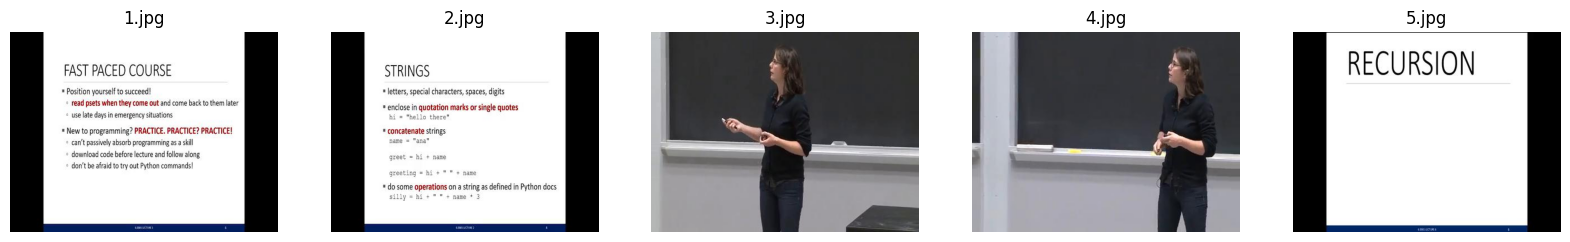

✅ Kadrai: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']


In [6]:
#@title 🎬 STEP 4: Extract Middle Frame
from PIL import Image
import matplotlib.pyplot as plt

frame_dir = "/content/frame-data/"
os.makedirs(frame_dir, exist_ok=True)

for filename in sorted(os.listdir(video_dir)):
    if filename.endswith(".mp4"):
        video = VideoFileClip(os.path.join(video_dir, filename))
        frame = video.get_frame(video.duration / 2.0)
        Image.fromarray(frame).save(os.path.join(frame_dir, os.path.splitext(filename)[0] + ".jpg"))
        video.close()

frames = sorted(os.listdir(frame_dir))
fig, axes = plt.subplots(1, len(frames), figsize=(4 * len(frames), 3))
for ax, name in zip(axes, frames):
    ax.imshow(Image.open(os.path.join(frame_dir, name)))
    ax.set_title(name)
    ax.axis("off")
plt.show()
print("✅ Kadrai:", frames)

## 💾 STEP 5: Išsaugojimas į Google Drive
Rezultatai supakuojami į zip failus Drive aplanke `colab-output-tmp`.

In [8]:
#@title 💾 STEP 5: Zip and Download
import shutil
from google.colab import files

for folder, name in [(video_dir, "video-data"), (audio_dir, "audio-data"),
                     (text_dir, "text-data"), (frame_dir, "frame-data")]:
    shutil.make_archive(f"/content/{name}", "zip", folder)
    files.download(f"/content/{name}.zip")
    print("✅", name + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ video-data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ text-data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ frame-data.zip
